# 학술제 분석 재현 및 개인 후속 고도화

이 노트북은 제4회 DArt-B 학술제 대상 수상 프로젝트의 핵심 결과를 정본 데이터에서 다시 확인하고, 역할별 분석·다음 등판 연결·시간 순서 기반 선발 예측·공개 투구 단위 데이터로 확장합니다.

## 분석 흐름

1. 정본 데이터와 점수 구조 확인
2. 학술제에서 발표한 같은 경기 성과 관계 재현
3. 김택연 선수 사례 재현
4. 선발·불펜 역할별 다음 등판 분석
5. 2024년 시간 외 선발 예측 실험
6. 공개 투구 단위 데이터로 구속·CSW·존 통과율 확장
7. 72.6 기준의 라벨별 민감도 확인

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from kbo_fatigue import (
    build_audit_metrics, correlation_summary, decile_summary,
    forward_validation_summary, load_dataset, load_pbp_features,
    process_signal_summary, temporal_starter_validation, validate_dataset,
    validate_pbp_features, within_appearance_velocity_summary,
)

DATA = ROOT / 'data' / 'final' / 'fatigue_with_index.csv'
PBP_DATA = ROOT / 'data' / 'external' / 'pbp_appearance_2023_2024.csv'

## 1. 정본 데이터와 점수 구조

학술제 발표자료에 명시된 2020–2024년 기록을 기준으로 기간, 선수 수, 중복 키와 점수 변환을 확인합니다.

In [2]:
df = load_dataset(DATA)
checks = validate_dataset(df)
pd.Series(checks, name='value').to_frame()

,value
rows,17528
players,163
date_min,2020-05-05
date_max,2024-10-01
years,"[2020, 2021, 2022, 2023, 2024]"
duplicate_player_dates,0
score_min,0.005705
score_max,100.0
percentile_rank_max_error,0.0
finite_scores,True


In [3]:
expected = df['피로도지수'].rank(method='average', pct=True) * 100
pd.DataFrame({
    'stored_score': df['피로도지수_점수'],
    'recalculated_percentile': expected,
    'absolute_error': (df['피로도지수_점수'] - expected).abs(),
}).describe().round(6)

,stored_score,recalculated_percentile,absolute_error
count,17528.000000,17528.000000,17528.0
mean,50.002853,50.002853,0.0
std,28.868337,28.868337,0.0
min,0.005705,0.005705,0.0
25%,25.004279,25.004279,0.0
50%,50.002853,50.002853,0.0
75%,75.001426,75.001426,0.0
max,100.000000,100.000000,0.0


## 2. 학술제 핵심 결과 재현: 같은 경기 성과 관계

학술제에서는 피로도 상승과 FIP·ERA·WHIP 상승, GS 하락을 보고했습니다. 아래에서는 현재 정본의 원점수로 관계의 방향과 크기를 다시 확인합니다.

In [4]:
presentation_results = pd.DataFrame({
    'metric': ['FIP', 'ERA', 'WHIP', 'GS'],
    'presentation_r': [0.504684, 0.550056, 0.758775, -0.496997],
    'presentation_r2': [0.254706, 0.302561, 0.575739, 0.247006],
})
reproduced = correlation_summary(df).rename(columns={'overall_r': 'current_raw_score_r'})
presentation_results.merge(reproduced, on='metric').round(4)

,metric,presentation_r,presentation_r2,current_raw_score_r,within_player_r
0,FIP,0.5047,0.2547,0.4822,0.4825
1,ERA,0.5501,0.3026,0.6374,0.6403
2,WHIP,0.7588,0.5757,0.8338,0.8365
3,GS,-0.4970,0.2470,-0.3890,-0.4507


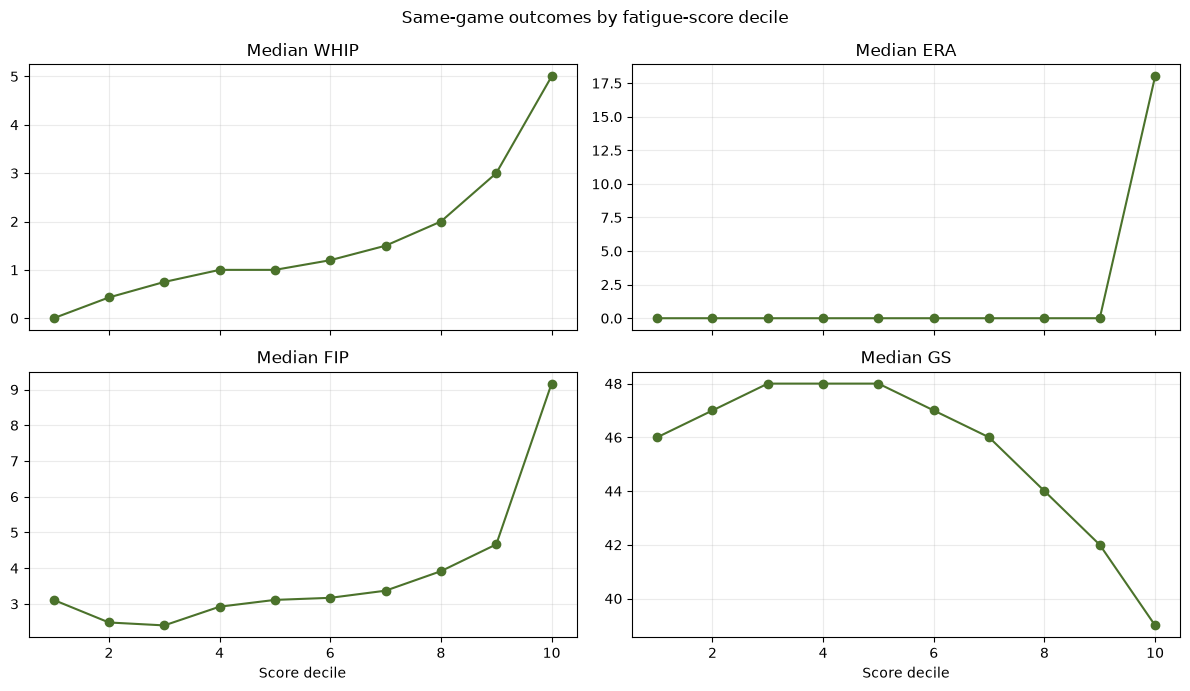

In [5]:
deciles = decile_summary(df)
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, metric in zip(axes.flat, ['WHIP', 'ERA', 'FIP', 'GS']):
    ax.plot(deciles['score_decile'], deciles[metric], marker='o', color='#4B722B')
    ax.set_title(f'Median {metric}')
    ax.grid(alpha=.25)
for ax in axes[-1]:
    ax.set_xlabel('Score decile')
plt.suptitle('Same-game outcomes by fatigue-score decile')
plt.tight_layout()
plt.show()

## 3. 발표 사례 재현: 김택연, 2024-08-24

발표자료의 핵심 사례를 정본에서 조회합니다. 점수는 99.977로 반올림하면 100이며 ERA 54.00, WHIP 9.00이 함께 확인됩니다.

In [6]:
kim_case = df.loc[
    df['선수'].eq('김택연') & df['날짜'].between('2024-08-15', '2024-09-01'),
    ['날짜', '피로도지수_점수', '투구수', '이닝', '휴식일수', 'ERA', 'WHIP', 'FIP', 'GS'],
].copy()
kim_case

,날짜,피로도지수_점수,투구수,이닝,휴식일수,ERA,WHIP,FIP,GS
5179,2024-08-15,73.123003,26,1.333333,5,0.0,0.75,1.666,48
5180,2024-08-17,80.317207,22,1.000000,1,0.0,3.00,2.166,44
5181,2024-08-18,56.834779,16,1.000000,0,9.0,1.00,12.166,44
5182,2024-08-21,69.796896,18,1.000000,2,0.0,1.00,1.166,46
5183,2024-08-24,99.977179,33,0.333333,2,54.0,9.00,12.166,37
5184,2024-08-27,59.111136,22,1.333333,2,0.0,0.00,1.666,49
5185,2024-09-01,36.364674,31,2.333333,4,0.0,1.71,1.880,52


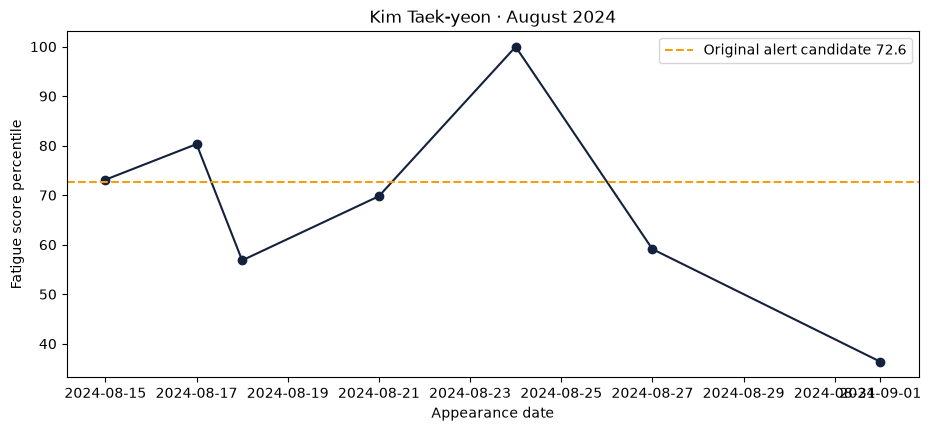

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(kim_case['날짜'], kim_case['피로도지수_점수'], marker='o', color='#14213D')
ax.axhline(72.6, color='#F59E0B', linestyle='--', label='Original alert candidate 72.6')
ax.set_xlabel('Appearance date')
ax.set_ylabel('Fatigue score percentile')
ax.set_title('Kim Taek-yeon · August 2024')
ax.legend()
plt.show()

## 4. 개인 후속 분석: 역할별 다음 등판

현재 점수를 같은 선수의 다음 동일 보직 등판과 연결합니다. 선발과 불펜을 분리함으로써 원 지수의 실제 활용 단위를 구체화합니다.

In [8]:
forward = forward_validation_summary(df)
forward.round(4)

,role,n,players,same_game_gs_r,next_appearance_gs_r,within_player_season_next_gs_r,below_72_6_next_gs_median,above_72_6_next_gs_median,above_72_6_n
0,ALL,17276,163,-0.3615,-0.0435,0.0059,46.0,45.0,4710
1,SP,3406,93,-0.7948,-0.1243,0.0152,64.0,60.0,505
2,RP,13870,146,-0.5422,-0.0173,0.0001,45.0,45.0,4205


선발에서는 현재 점수와 다음 GS가 약한 음의 관계를 보이고, 72.6 이상 등판의 다음 GS 중앙값이 4점 낮았습니다. 불펜은 다음 GS 차이가 없으므로 GS 대신 불펜 운용에 맞는 FIP·WHIP·gmLI·WPA·RE24 타깃으로 확장하는 것이 적절합니다.

## 5. 개인 후속 분석: 시간 순서 기반 다음 선발 예측

workload와 최근 폼으로 다음 선발 GS를 예측합니다. 2023년으로 Ridge alpha를 선택하고 2024년을 한 번만 최종 평가합니다.

In [9]:
starter_model = temporal_starter_validation(df)
pd.Series({
    'selected_alpha': starter_model['selected_alpha'],
    'train_n': starter_model['train_n'],
    'test_n': starter_model['test_n'],
    '2024_model_MAE': starter_model['model']['mae'],
    '2024_model_RMSE': starter_model['model']['rmse'],
    '2024_model_R2': starter_model['model']['r2'],
    'mean_baseline_MAE': starter_model['mean_baseline']['mae'],
    'MAE_improvement_pct': starter_model['mae_improvement_pct'],
}, name='value').to_frame()

,value
selected_alpha,1000.0000
train_n,2452.0000
test_n,861.0000
2024_model_MAE,9.7332
2024_model_RMSE,12.2211
2024_model_R2,0.0841
mean_baseline_MAE,10.1681
MAE_improvement_pct,4.2800


In [10]:
(pd.Series(starter_model['standardized_coefficients'])
 .sort_values(key=lambda values: values.abs(), ascending=False)
 .to_frame('standardized_coefficient'))

,standardized_coefficient
GS_roll5,1.0940
GS_roll3,0.5772
이닝_roll3,0.4986
이닝,0.4651
투구수_roll3,0.3435
투구수,0.2627
연투횟수,-0.2574
휴식일수,-0.1460
휴식대연투비율,-0.1191
NP/IP,-0.0594


## 6. 공개 투구 단위 데이터 확장

CC BY 4.0 KBO play-by-play 자료의 2023–2024 시즌을 연결해 경기 결과보다 앞선 구속 유지, CSW, 존 통과율을 확인합니다. 원본 revision과 SHA-256은 생성 스크립트에 고정했습니다.

In [11]:
pbp = load_pbp_features(PBP_DATA)
pbp_checks = validate_pbp_features(pbp, df)
pd.Series(pbp_checks, name='value').to_frame()

,value
rows,7924
players,128
date_min,2023-04-01
date_max,2024-10-01
years,"[2023, 2024]"
duplicate_player_dates,0
multiple_pitcher_id_rows,0
pitch_count_exact_rate,0.99369
late_velocity_available_rate,0.795053
canonical_coverage_rate,0.974542


In [12]:
process = process_signal_summary(df, pbp)
velocity = within_appearance_velocity_summary(df, pbp)
display(velocity.round(4))
display(process.round(4))

,role,n,players,score_r,below_72_6_median,above_72_6_median,high_minus_low,cluster_bootstrap_ci_low,cluster_bootstrap_ci_high
0,SP,1534,70,-0.1265,-1.00,-1.2857,-0.2857,NaN,NaN
1,RP,4766,113,-0.0522,0.25,0.0000,-0.2500,NaN,NaN


,role,metric,n,players,score_r,below_72_6_median,above_72_6_median,high_minus_low,cluster_bootstrap_ci_low,cluster_bootstrap_ci_high
0,SP,pbp_csw_rate,1398,64,-0.0570,0.2778,0.2738,-0.0040,NaN,NaN
1,SP,pbp_zone_rate,1383,64,-0.0533,0.4726,0.4681,-0.0045,NaN,NaN
2,SP,pbp_hard_velocity,1398,64,0.0142,142.2632,141.6667,-0.5965,NaN,NaN
3,RP,pbp_csw_rate,6167,105,0.0024,0.2727,0.2692,-0.0035,NaN,NaN
4,RP,pbp_zone_rate,6091,105,-0.0248,0.4615,0.4615,0.0000,NaN,NaN
5,RP,pbp_hard_velocity,6094,105,0.0355,143.9000,144.0000,0.1000,NaN,NaN


선발의 등판 후반 강한 공 구속은 72.6 미만에서 초반 대비 중앙값 1.00km/h, 72.6 이상에서 1.29km/h 낮았습니다. 다음 등판 CSW·존 통과율·구속 차이의 선수 단위 신뢰구간은 0을 포함하므로, 현재는 같은 경기의 과정 모니터링 신호로 활용하고 미래 상태는 복수 지표로 판단합니다.

## 7. 72.6 기준의 라벨별 민감도

학술제의 72.6 기준을 회복·부상 자동 분류 규칙으로 확장하려면 실제 결과 라벨과 외부 시즌 검증이 필요합니다. 현재 저장된 대리 라벨에 대한 AUC를 후속 참고 지표로 남깁니다.

In [13]:
metrics = build_audit_metrics(df)
pd.Series(metrics['classification_diagnostics']).to_frame('value')

,value
recovery_failure_auc,0.5143
injury_proxy_auc,0.5079
injury_proxy_definition,부상위험도가 결측이 아니고 0보다 큰 행


## 결론

- 학술제에서 제시한 피로도와 같은 경기 성과의 관계 및 김택연 사례가 정본에서 재현됐습니다.
- 개인 후속 분석은 선발과 불펜을 분리하고 다음 동일 보직 등판을 연결해 적용 범위를 구체화했습니다.
- 선발의 다음 GS에서는 약한 신호가 확인됐으며, 시간 순서 기반 기준 모델은 2024년 평균 기준선 대비 MAE를 4.3% 개선했습니다.
- 공개 투구 단위 자료 7,924등판을 결합해 구속 유지·CSW·존 통과율을 추가하고, 미래 신호의 불확실성까지 함께 제시했습니다.
- 향후에는 불펜 전용 레버리지 타깃, 실제 부상·회복 라벨, 구종별 무브먼트와 릴리스 포인트를 추가해 원 의사결정 도구를 확장합니다.